 # SMOTE - Only numerical data
 # SMOTENC - Both numerical and categorical data
 # SMOTEN - Only categorical data
 # ADASYN - When SMOTE is not enough & it focuses on hard samples(minority point surrounded by majority classes)
 # BorderlineSMOTE - Near decision boundary
 # KMeansSMOTE - Clustering + SMOTE
 # SVMSMOTE - SVM finds boundary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('datasets\\creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
df.duplicated().sum()

1081

In [5]:
df.shape

(284807, 31)

In [8]:
#import pandas_profiling
#df.profile_report()

In [9]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [11]:
df[['Time','Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


In [12]:
df['Amount'].skew()

16.977724453761024

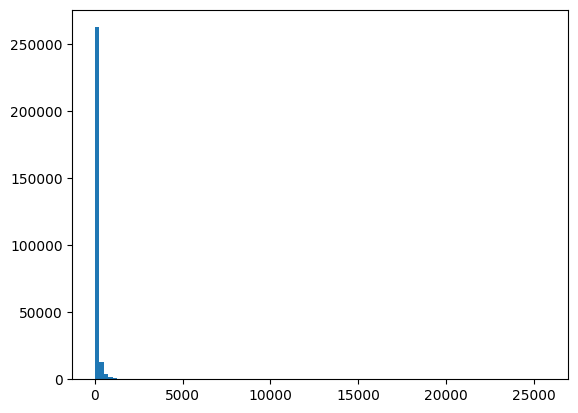

In [17]:
plt.hist(df['Amount'], bins=100)
plt.show()

In [18]:
df.groupby("Class")['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [19]:
df.groupby('Class')['Time'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,94838.202258,47484.015786,0.0,54230.0,84711.0,139333.0,172792.0
1,492.0,80746.806911,47835.365138,406.0,41241.5,75568.5,128483.0,170348.0


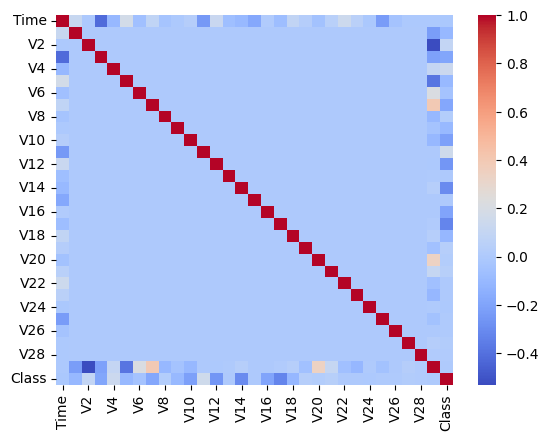

In [21]:
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.show()

In [24]:
corr['Class'].sort_values(ascending = False)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

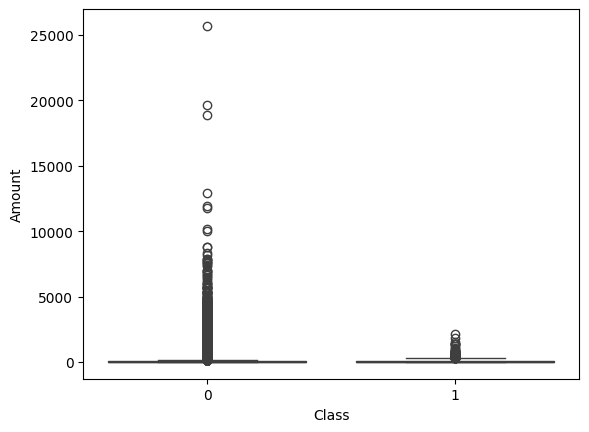

In [30]:
sns.boxplot(df, x='Class', y='Amount')
plt.show()

In [31]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


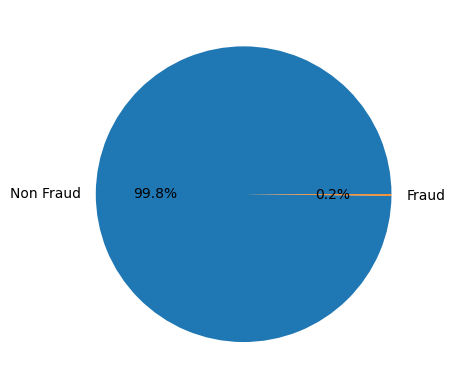

In [36]:
plt.pie(df['Class'].value_counts(), labels = ['Non Fraud', 'Fraud'], autopct='%1.1f%%')
plt.show()

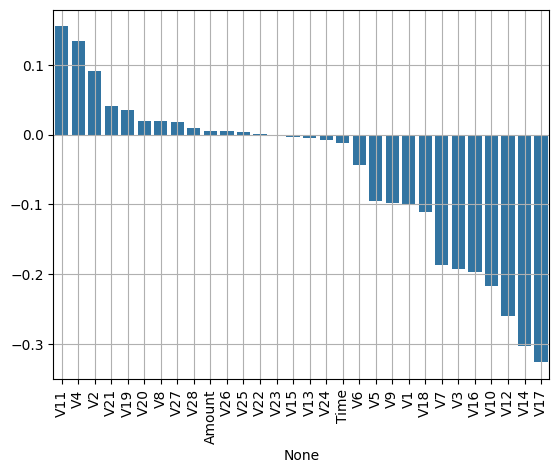

In [47]:
corr_class = corr['Class'].sort_values(ascending=False)[1:]
sns.barplot(x=corr_class.index, y=corr_class.values)
plt.xticks(rotation = 90)
plt.grid(True)
plt.show()

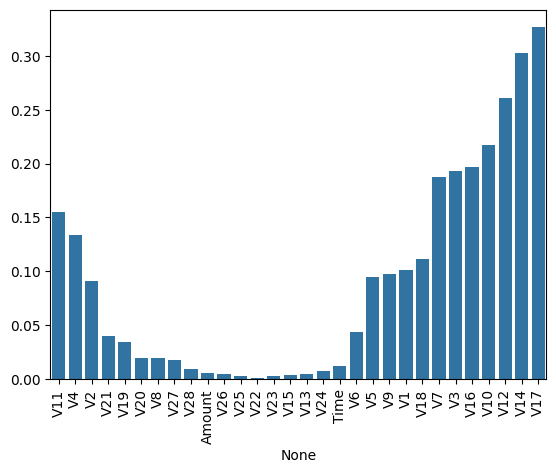

In [45]:
corr_class = corr['Class'].sort_values(ascending=False)[1:]
sns.barplot(x=corr_class.index, y=abs(corr_class.values))
plt.xticks(rotation = 90)
plt.show()

In [49]:
df.duplicated().sum()

1081

In [51]:
df[df.duplicated()]['Class'].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

In [54]:
idx = df[df.duplicated() & (df['Class'] == 0)].index
df = df.drop(idx)

In [55]:
df.duplicated().sum()

19

In [56]:
X = df.drop("Class", axis = 1)
y = df['Class']
X.shape, y.shape

((283745, 30), (283745,))

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 7)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled.shape, X_test_scaled.shape

((226996, 30), (56749, 30))

In [59]:
y_train.value_counts(), y_test.value_counts()

(Class
 0    226602
 1       394
 Name: count, dtype: int64,
 Class
 0    56651
 1       98
 Name: count, dtype: int64)

In [60]:
y_train.value_counts(normalize = True), y_test.value_counts(normalize=True)

(Class
 0    0.998264
 1    0.001736
 Name: proportion, dtype: float64,
 Class
 0    0.998273
 1    0.001727
 Name: proportion, dtype: float64)

In [62]:
def train_model(xt,yt):
    model = LogisticRegression()
    model.fit(xt, yt)
    return model

In [64]:
logistic = train_model(X_train_scaled, y_train)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
def predict_model(model, xtest, ytest):
    y_pred = model.predict(xtest)
    print("Accuracy: ", accuracy_score(ytest, y_pred))
    print(classification_report(ytest, y_pred))
    print(confusion_matrix(ytest, y_pred))

predict_model(logistic, X_test_scaled, y_test)

Accuracy:  0.999277520308728
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.62      0.75        98

    accuracy                           1.00     56749
   macro avg       0.97      0.81      0.87     56749
weighted avg       1.00      1.00      1.00     56749

[[56647     4]
 [   37    61]]


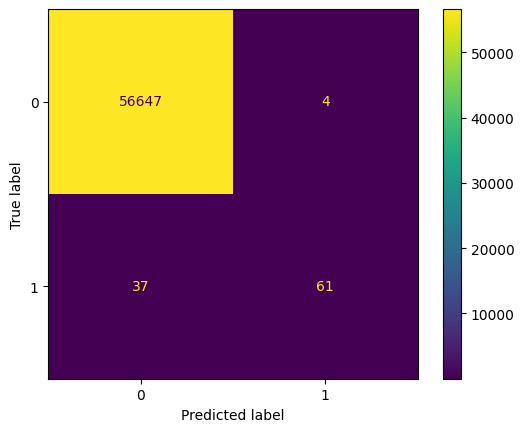

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay
mat = confusion_matrix(y_test, logistic.predict(X_test_scaled))
ConfusionMatrixDisplay(mat, display_labels = logistic.classes_).plot()
plt.show()

In [69]:
y_probs = logistic.predict_proba(X_test_scaled)
threshold = 0.3
y_pred = (y_probs[:,1] >= threshold).astype(int)
def metrics(ytest, ypred):
    print("Accuracy: ", accuracy_score(ytest, ypred))
    print(classification_report(ytest, ypred))
    print(confusion_matrix(ytest, ypred))

metrics(y_test, y_pred)

Accuracy:  0.9993127632204972
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.68      0.77        98

    accuracy                           1.00     56749
   macro avg       0.95      0.84      0.89     56749
weighted avg       1.00      1.00      1.00     56749

[[56643     8]
 [   31    67]]


In [70]:
logistic_withbal = LogisticRegression(class_weight='balanced')
logistic_withbal.fit(X_train_scaled, y_train)
pred = logistic_withbal.predict(X_test_scaled)
metrics(y_test, pred)

Accuracy:  0.9764929778498299
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56749
   macro avg       0.53      0.95      0.55     56749
weighted avg       1.00      0.98      0.99     56749

[[55325  1326]
 [    8    90]]


In [ ]:
# technique 2 = resampling(under sampling) the data

In [72]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=7)
X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train)
print(f"Before resampling: {y_train.value_counts()}")
print(f"After resampling: {y_rus.value_counts()}")

Before resampling: Class
0    226602
1       394
Name: count, dtype: int64
After resampling: Class
0    394
1    394
Name: count, dtype: int64


In [73]:
model_rus = LogisticRegression()
model_rus.fit(X_rus, y_rus)
pred = model_rus.predict(X_test_scaled)
metrics(y_test, pred)

Accuracy:  0.9549419373028599
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56651
           1       0.03      0.92      0.07        98

    accuracy                           0.95     56749
   macro avg       0.52      0.94      0.52     56749
weighted avg       1.00      0.95      0.98     56749

[[54102  2549]
 [    8    90]]


In [74]:
# technique 3 = resampling(SMOTE) 

In [75]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 7)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Before resampling: {y_train.value_counts()}")
print(f"After resampling: {y_smote.value_counts()}")

Before resampling: Class
0    226602
1       394
Name: count, dtype: int64
After resampling: Class
0    226602
1    226602
Name: count, dtype: int64


In [77]:
model_smote = LogisticRegression(max_iter=1000, random_state=7)
model_smote.fit(X_smote, y_smote)
pred = model_smote.predict(X_test_scaled)
metrics(y_test, pred)

Accuracy:  0.9733739801582407
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.06      0.94      0.11        98

    accuracy                           0.97     56749
   macro avg       0.53      0.96      0.55     56749
weighted avg       1.00      0.97      0.98     56749

[[55146  1505]
 [    6    92]]


In [79]:
smote = SMOTE(sampling_strategy = 0.1, random_state = 7)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Before resampling: {y_train.value_counts()}")
print(f"After resampling: {y_smote.value_counts()}")

Before resampling: Class
0    226602
1       394
Name: count, dtype: int64
After resampling: Class
0    226602
1     22660
Name: count, dtype: int64


In [80]:
model_smote = LogisticRegression(max_iter=1000, random_state=7)
model_smote.fit(X_smote, y_smote)
pred = model_smote.predict(X_test_scaled)
metrics(y_test, pred)

Accuracy:  0.9978854252938377
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.44      0.85      0.58        98

    accuracy                           1.00     56749
   macro avg       0.72      0.92      0.79     56749
weighted avg       1.00      1.00      1.00     56749

[[56546   105]
 [   15    83]]


In [81]:
smote = SMOTE(sampling_strategy = 0.2, random_state = 7)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Before resampling: {y_train.value_counts()}")
print(f"After resampling: {y_smote.value_counts()}")
model_smote = LogisticRegression(max_iter=1000, random_state=7)
model_smote.fit(X_smote, y_smote)
pred = model_smote.predict(X_test_scaled)
metrics(y_test, pred)

Before resampling: Class
0    226602
1       394
Name: count, dtype: int64
After resampling: Class
0    226602
1     45320
Name: count, dtype: int64
Accuracy:  0.9948721563375567
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.23      0.87      0.37        98

    accuracy                           0.99     56749
   macro avg       0.62      0.93      0.68     56749
weighted avg       1.00      0.99      1.00     56749

[[56373   278]
 [   13    85]]


# New code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('datasets\\creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [6]:
df.groupby("Class")['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [15]:
X = df.drop("Class", axis = 1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train set: {X_train.shape[0]:,} samples")
print(f"Test set:  {X_test.shape[0]:,} samples")
print(f"\nTrain — Fraud: {y_train.sum()}, Legit: {(y_train==0).sum()}")
print(f"Test  — Fraud: {y_test.sum()}, Legit: {(y_test==0).sum()}")

Train set: 227,845 samples
Test set:  56,962 samples

Train — Fraud: 394, Legit: 227451
Test  — Fraud: 98, Legit: 56864


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Logistic Regression
lr_naive = LogisticRegression()
lr_naive.fit(X_train_scaled, y_train)

y_pred = lr_naive.predict(X_test_scaled)
y_prob = lr_naive.predict_proba(X_test_scaled)[:, 1]
y_prob

array([6.66589547e-05, 3.65855419e-05, 6.07869423e-06, ...,
       1.57444972e-05, 6.55799815e-05, 2.65939507e-04])

In [18]:
def metrics(ytest, ypred):
    print("Accuracy: ", accuracy_score(ytest, ypred))
    print("Precision: ", precision_score(ytest, ypred))
    print("Recall: ", recall_score(ytest, ypred))
    print("F1 Score: ", f1_score(ytest, ypred))
    print("ROC AUC Score: ", roc_auc_score(ytest, ypred))
    print(classification_report(ytest, ypred))
    print(confusion_matrix(ytest, ypred))

In [19]:
metrics(y_test, y_pred)

Accuracy:  0.9991397773954567
Precision:  0.8266666666666667
Recall:  0.6326530612244898
F1 Score:  0.7167630057803468
ROC AUC Score:  0.8162122227900727
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

[[56851    13]
 [   36    62]]


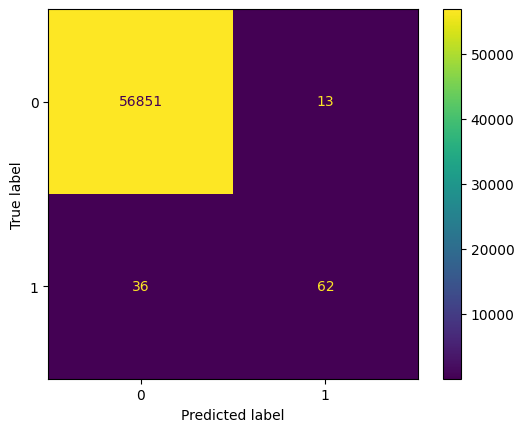

In [20]:
mat = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(mat, display_labels=lr_naive.classes_).plot()
plt.show()

In [23]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)
y_pred_dummy

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [24]:
metrics(y_test, y_pred_dummy)

Accuracy:  0.9982795547909132
Precision:  0.0
Recall:  0.0
F1 Score:  0.0
ROC AUC Score:  0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962

[[56864     0]
 [   98     0]]


C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(

In [25]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=7, sampling_strategy=0.1)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [29]:
lr_naive = LogisticRegression(max_iter=1000, random_state=7)
lr_naive.fit(X_train_scaled, y_train)
y_prob_naive = lr_naive.predict_proba(X_test_scaled)[:,1]

In [30]:
lr_smote = LogisticRegression(max_iter=1000, random_state=7)
lr_smote.fit(X_train_smote, y_train_smote)
y_prob_smote = lr_smote.predict_proba(X_test_scaled)[:,1]

In [31]:
dt_smote = DecisionTreeClassifier(max_depth=10, random_state=7)
dt_smote.fit(X_train_smote, y_train_smote)
y_prob_dt = dt_smote.predict_proba(X_test_scaled)[:,1]

In [32]:
rf_smote = RandomForestClassifier(n_estimators = 100, max_depth=10, random_state=7)
rf_smote.fit(X_train_smote, y_train_smote)
y_prob_rf = rf_smote.predict_proba(X_test_scaled)[:,1]

In [35]:
fpr_naive, tpr_naive, threshold_naive = roc_curve(y_test, y_prob_naive)
print(tpr_naive[0:10], fpr_naive[0:10], threshold_naive[0:10])

[0.         0.01020408 0.13265306 0.15306122 0.17346939 0.17346939
 0.19387755 0.19387755 0.24489796 0.24489796] [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.75858188e-05 1.75858188e-05 3.51716376e-05
 3.51716376e-05 5.27574564e-05] [       inf 1.         0.99999982 0.99999982 0.99999964 0.99999097
 0.99997315 0.99995932 0.99975086 0.99973863]


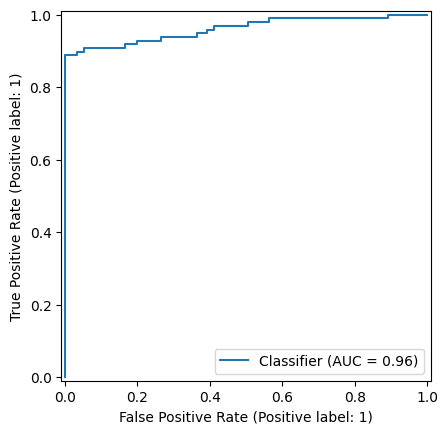

In [36]:
from sklearn.metrics import RocCurveDisplay,roc_curve
RocCurveDisplay.from_predictions(y_test, y_prob_naive)
plt.show()

In [40]:
thresholds = np.arange(0.05,0.96,0.05)
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1 Score':>10} {'TP':>10} {'FP':>10} {'TN':>10} {'FN':>10} {'TPR':>10} {'FPR':>10}")
best_f1 = 0
best_t = 0.5
for t in thresholds:
    y_pred = (y_prob_naive >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    precision = tp / (tp+fp) if (tp+fp)>0 else 0
    recall = tp/ (tp+fn) if (tp+fn) > 0 else 0
    f1 = 2 * precision * recall / (precision+recall) if (precision+recall) > 0 else 0
    tpr = recall
    fpr = fp/(fp+tn) 
    if f1 > best_f1:
        best_f1 = f1
        best_t = t
    print(f"{t:10.2f} {precision:10.2f} {recall:10.2f} {f1:10.2f} {tp:10d} {fp:10d} {tn:10d} {fn:10d} {tpr:10.2f} {fpr:10.2f}")
print(f"\nBest F1 Score: {best_f1:.2f} at Threshold: {best_t:.2f}")

 Threshold  Precision     Recall   F1 Score         TP         FP         TN         FN        TPR        FPR
      0.05       0.65       0.83       0.73         81         43      56821         17       0.83       0.00
      0.10       0.70       0.77       0.73         75         32      56832         23       0.77       0.00
      0.15       0.73       0.77       0.75         75         28      56836         23       0.77       0.00
      0.20       0.73       0.73       0.73         72         26      56838         26       0.73       0.00
      0.25       0.73       0.71       0.72         70         26      56838         28       0.71       0.00
      0.30       0.73       0.69       0.71         68         25      56839         30       0.69       0.00
      0.35       0.74       0.67       0.71         66         23      56841         32       0.67       0.00
      0.40       0.75       0.65       0.70         64         21      56843         34       0.65       0.00
      0.45

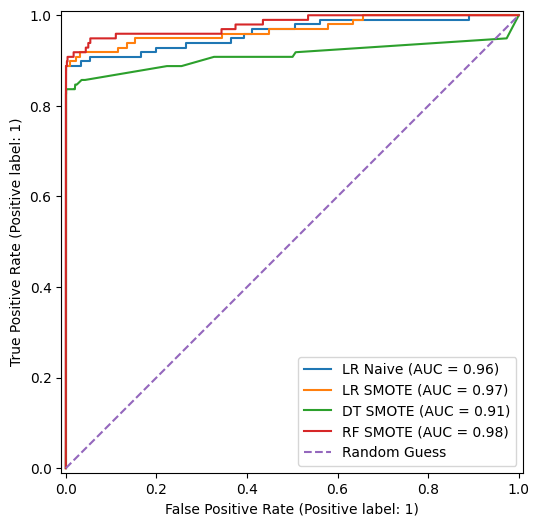

In [50]:
models = {
    'LR Naive': y_prob_naive,
    'LR SMOTE': y_prob_smote,
    'DT SMOTE': y_prob_dt,
    'RF SMOTE': y_prob_rf
}
fig, ax = plt.subplots(figsize=(8,6))
for name, probs in models.items():
    RocCurveDisplay.from_predictions(y_test, probs, name=name,ax=ax)
ax.plot([0,1], [0,1], '--', label='Random Guess')
ax.legend(loc='lower right')
plt.show()

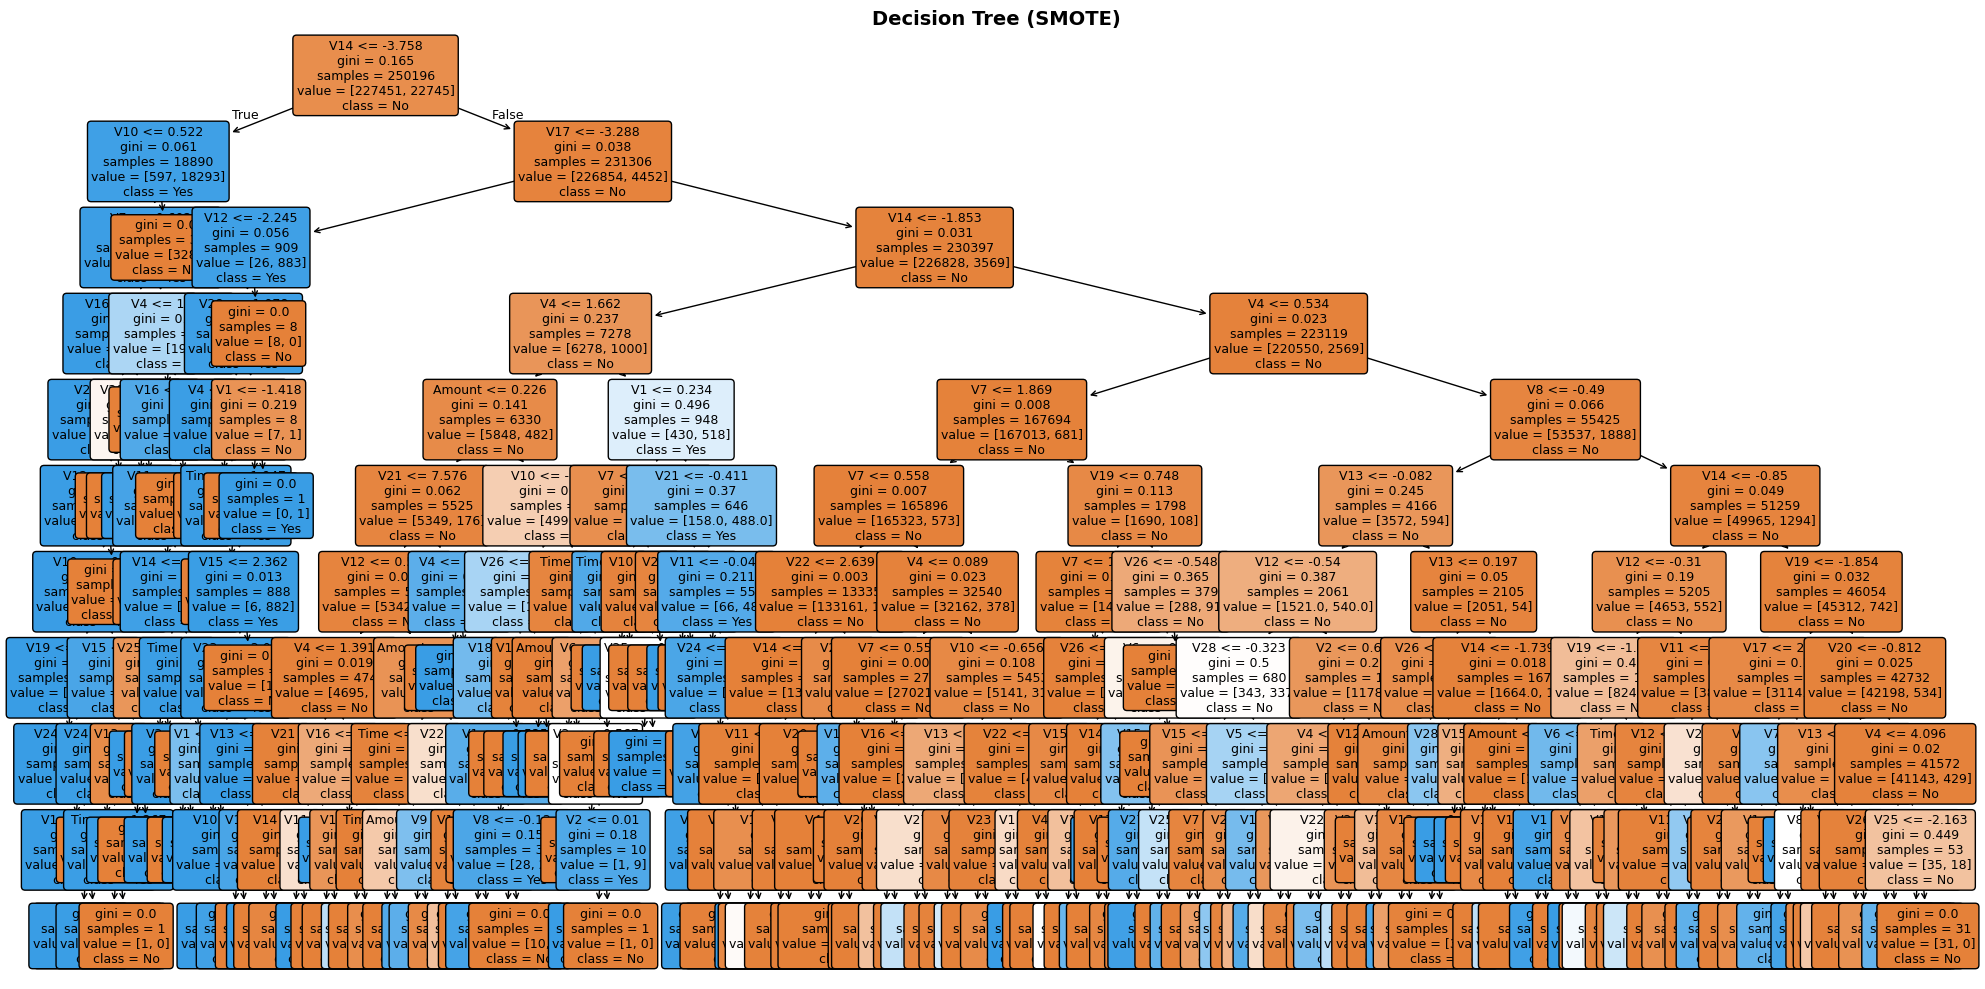

In [51]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_smote, feature_names=X_train.columns, class_names=['No', 'Yes'],
          filled=True, rounded=True, ax=ax, fontsize=9)
plt.title('Decision Tree (SMOTE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
